# Summary statistics for the dataset

This notebook plots the initial descriptive graphs for the various baseline variables. 

In [1]:
import pandas as pd
import numpy as np
import math 
import matplotlib.pyplot as plt
import geopandas as gpd

from elasticsearch import Elasticsearch

from database.comments import Comments

import sys
sys.path.append('../functions')
import preprocessing_fncs as ppf
from elastic_search_fncs import ElasticSearchFncs

### Dataset 1 - geo boundaries 
This is the .geojson file of the boundaries of the london authorities. 

In [2]:
london_lad = gpd.read_file('../data/london_geos/Local_Authority_Districts_May_2024_London.geojson')

### Dataset 2 - applications
This is the .csv file extracted from the Planning London Datahub which was used to identify applications for webscraping. 

In [3]:
# Application dataset 
application_df_path = "/Users/bea/Documents/AI4CI/projects/comment_summariser/comment_summariser/data/PLD_application_ids/all_since21_cleaned.csv"
application_df = pd.read_csv(application_df_path)
print(f"There are {len(application_df)} applications in the dataset.")

# drop 'Bromley' applications -  since I haven't been able to get the comments for these
application_df = application_df[application_df['borough'] != 'Bromley']
print(f"There are {len(application_df)} applications in the dataset after dropping Bromley applications.")

application_df = ppf.format_df(application_df, 'borough')

There are 5850 applications in the dataset.
There are 5077 applications in the dataset after dropping Bromley applications.


### Dataset 3 - comments 
This is the remote database of comments resulting from webscraping. This dataset matches to the planning applications on 'application_id'. 

In [4]:
# Comments dataset
cs = Comments()
comment_df = cs.read_all().copy()
comment_df = ppf.format_borough(comment_df, 'council')

comment_df.head()

Connecting to the ai4ci-db-dev database...
Successfully connected to ai4ci-db-dev.


,id,council,comment_id,application_id,address,stance,date,comment_text,add_date,lat,lon,cleaned_comment_text,lsoa_code,sentiment_score
0,88439,Barnet,23/4221/FUL_13,23/4221/FUL,45 Pine Grove Totteridge London N20 8LA,Objects,2023-11-08,I object to the proposed planning application ...,2025-04-10,51.632395,-0.194255,I object to the proposed planning application ...,E09000003,-0.244143
1,94013,Ealing,215737FUL_2,215737FUL,53 Gordon Road Ealing London W5 2AL W5 2AL,Objects,2021-10-30,I am writing as Chair of the GRASS (Gordon Roa...,2025-04-11,51.514611,-0.311787,I am writing as Chair of the GRASS ( and Surro...,E09000009,-0.232367
2,106710,Ealing,230760FUL_6,230760FUL,19 Studley Grange Road Hanwell W7 2Lu W7 2Lu,Objects,2023-09-24,"Dear Sir/Madam,\n\nAs a direct neighbour (on t...",2025-05-01,51.503314,-0.336865,"Dear Sir/Madam,\n\nAs a direct neighbour (on t...",E09000009,-0.167873
3,88908,Brent,20/0115_42,20/0115,"34 Gratton Terrace, London, NW2 6QE",Objects,2020-06-11,11/06/2020 - Further objection comment receive...,2025-04-10,51.560030,-0.218620,11/06/2020 - Further objection comment receive...,E09000003,-0.315872
4,76007,Barnet,22/4044/FUL_2,22/4044/FUL,8 May's Lane Barnet EN5 2EE,Objects,2022-09-05,CONTINUED\nArticle 8 of the Human Rights Act s...,2025-04-08,51.645724,-0.203315,CONTINUED\nArticle 8 of the Human Rights Act s...,E09000003,-0.229557


In [5]:
print(f"The councils in the dataset are: {comment_df['council'].unique()}")
print(f"Total number of comments: {len(comment_df)}")
print(f"Total number of applications (with at least one comment scraped): {len(comment_df.application_id.unique())}")

The councils in the dataset are: ['Barnet' 'Ealing' 'Brent' 'Newham' 'Westminster' 'Lambeth' 'Southwark'
 'City of London']
Total number of comments: 30393
Total number of applications (with at least one comment scraped): 2453


In [6]:
comment_df.groupby("application_id").size().describe()

count    2453.000000
mean       12.390135
std        42.732741
min         1.000000
25%         1.000000
50%         3.000000
75%         8.000000
max       844.000000
dtype: float64

In [7]:
# Count unique apps and comments per council
comment_stats = (
    comment_df
    .groupby('council')[['application_id', 'comment_id']]
    .nunique()
    .rename(columns={
        'application_id': 'no_applications_with_comments',
        'comment_id': 'total_comment_count'
    })
    .reset_index()
)

# Compute mean comments per application
comment_stats['mean_comments_per_application'] = (
    comment_stats['total_comment_count'] / comment_stats['no_applications_with_comments']
)

# Count total applications per borough/council
application_counts = (
    application_df
    .groupby('borough')
    .size()
    .rename('no_applications')
    .reset_index()
)

# Merge and sort
unique_app_counts = (
    comment_stats
    .merge(application_counts, left_on='council', right_on='borough', how='left')
    .drop(columns='borough')
    .sort_values('no_applications')
)

unique_app_counts


,council,no_applications_with_comments,total_comment_count,mean_comments_per_application,no_applications
2,City of London,14,38,2.714286,21
6,Southwark,152,2488,16.368421,308
5,Newham,158,750,4.746835,424
4,Lambeth,208,2587,12.437500,483
7,Westminster,238,1347,5.659664,493
1,Brent,395,2419,6.124051,935
3,Ealing,497,11592,23.323944,1122
0,Barnet,791,9172,11.595449,1291


### Local authority plot 

Plot a map of London with the local authorities with web-scraped data higlighted 

In [8]:
# list of councils to highlight
councils = unique_app_counts['council'].tolist()

In [9]:
# format comment_df lat and lon to london_lad crs
# assuming original are (EPSG:27700)
comment_gdf = gpd.GeoDataFrame(
    comment_df,
    geometry=gpd.points_from_xy(comment_df.lon, comment_df.lat),
    crs="EPSG:4326"
)

comment_gdf = comment_gdf.to_crs(london_lad.crs)

In [10]:
# function for assigning location of the text label when plotting 
def assign_side(row, minx, maxx, miny, maxy):
    x, y = row['centroid_x'], row['centroid_y']
    # Calculate distances to each edge
    dist_left = abs(x - minx)
    dist_right = abs(maxx - x)
    dist_bottom = abs(y - miny)
    dist_top = abs(maxy - y)

    # Assign side by minimum distance to bounding box edge
    distances = {'left': dist_left, 'right': dist_right, 'top': dist_top, 'bottom': dist_bottom}
    assigned_side = min(distances, key=distances.get)
    return assigned_side

In [11]:
# Bounding box
minx, miny, maxx, maxy = london_lad.total_bounds
x_margin = (maxx - minx) * 0.05
y_margin = (maxy - miny) * 0.05

highlighted = london_lad[london_lad['LAD24NM'].isin(councils)].copy()
highlighted['centroid'] = highlighted.geometry.centroid

# Sort based on y or x using `.apply()` to extract coords
highlighted['centroid_x'] = highlighted['centroid'].apply(lambda point: point.x)
highlighted['centroid_y'] = highlighted['centroid'].apply(lambda point: point.y)

highlighted['side'] = highlighted.apply(assign_side, axis=1, args=(minx, maxx, miny, maxy))

/var/folders/4n/x6w1yfcx01qbymrsfpz4ybq00000gn/T/ipykernel_21782/64958339.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  highlighted['centroid'] = highlighted.geometry.centroid


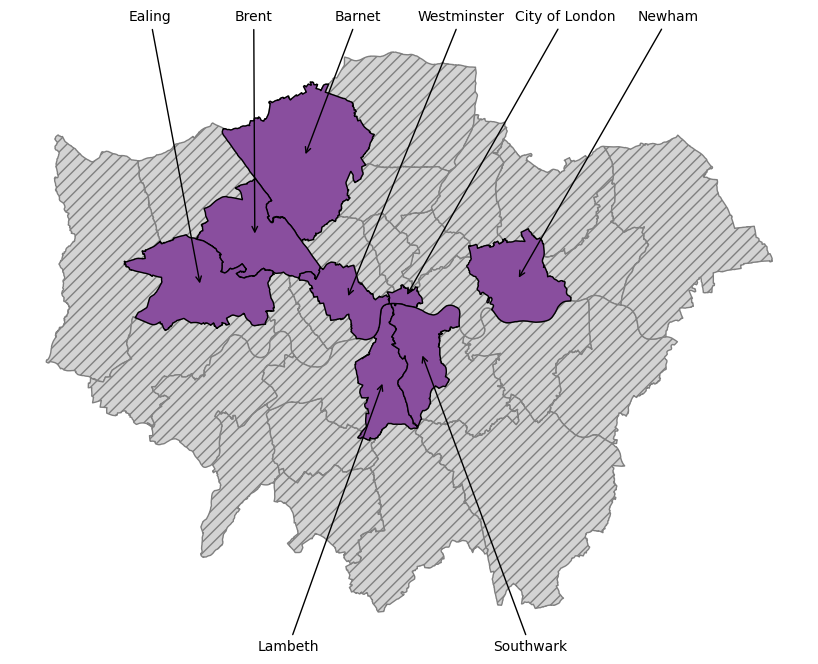

In [12]:
# Create a new column to indicate if the council is in the councils array
london_lad['highlight'] = london_lad['LAD24NM'].apply(lambda x: x in councils)

# Plot the GeoDataFrame
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
london_lad.plot(ax=ax, color='lightgrey', edgecolor='grey', hatch="///")  # Default color for all areas
london_lad[london_lad['highlight']].plot(ax=ax, color="#894e9e", edgecolor='black')  # Highlighted councils

# # add scatter of comments - comment out to get map without scatter 
# ax.scatter(
#     comment_gdf['lon'],
#     comment_gdf['lat'],
#     s=10,
#     color="#a0e8ef",
#     alpha=0.2,
#     label='Comments'
# )  

def annotate_side(df, side):
    # Sort the df by coordinate axis to get label order
    if side in ['left', 'right']:
       df = df.sort_values(by='centroid_y')  # south → north
    else:  # 'top' or 'bottom'
        df = df.sort_values(by='centroid_x')  # west → east
    
    n = len(df)
    if side in ['left', 'right']:
        # evenly space labels vertically
        y_positions = np.linspace(miny, maxy, n + 2)[1:-1]
        for i, (idx, row) in enumerate(df.iterrows()):
            cx, cy = row['centroid_x'], row['centroid_y']
            if side == 'left':
                lx, ly = minx - x_margin, y_positions[i]
                ha, va = 'right', 'center'
            else:  # right
                lx, ly = maxx + x_margin, y_positions[i]
                ha, va = 'left', 'center'

            ax.annotate(
                row['LAD24NM'],
                xy=(cx, cy),
                xytext=(lx, ly),
                textcoords='data',
                arrowprops=dict(arrowstyle='->', color='black', lw=1),
                fontsize=10,
                ha=ha,
                va=va,
                color='black'
            )
    else:
        # evenly space labels horizontally
        x_positions = np.linspace(minx, maxx, n + 2)[1:-1]
        for i, (idx, row) in enumerate(df.iterrows()):
            cx, cy = row['centroid_x'], row['centroid_y']
            if side == 'top':
                lx, ly = x_positions[i], maxy + y_margin
                ha, va = 'center', 'bottom'
            else:  # bottom
                lx, ly = x_positions[i], miny - y_margin
                ha, va = 'center', 'top'

            ax.annotate(
                row['LAD24NM'],
                xy=(cx, cy),
                xytext=(lx, ly),
                textcoords='data',
                arrowprops=dict(arrowstyle='->', color='black', lw=1),
                fontsize=10,
                ha=ha,
                va=va,
                color='black'
            )

for side, group in highlighted.groupby('side'):
    annotate_side(group, side)

ax.set_axis_off()

plt.savefig("../results/figures/just_london_councils_highlighted.png", dpi=500)
plt.show()

### Local authority barchart 
Plot stacked vertical bar chart showing the number of applications and the proportion receiving comments. 

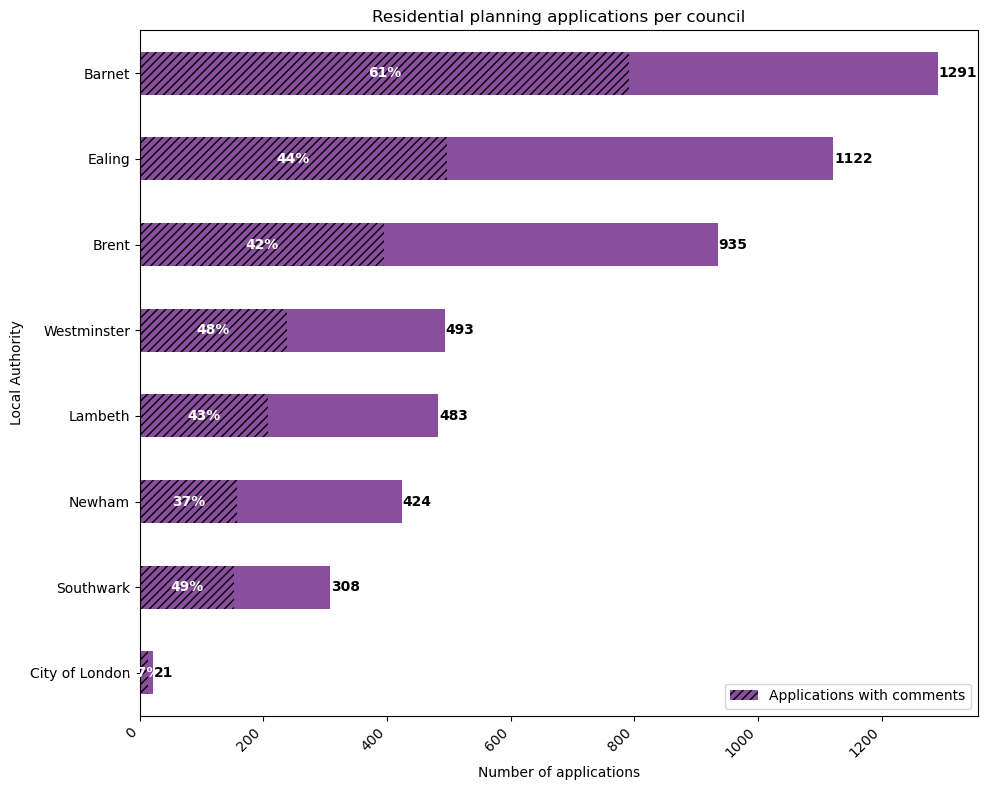

In [13]:
# make a copy to avoid modifying original
df = unique_app_counts.copy()

# compute the remainder (total minus subset). Clip to 0 to avoid negatives if data odd.
df['no_applications_remaining'] = (df['no_applications'] - df['no_applications_with_comments']).clip(lower=0)

# plot stacked bars: first the subset, then the remainder so subset is at the left of the bar
ax = df.plot.barh(
    x='council',
    y=['no_applications_with_comments', 'no_applications_remaining'],
    stacked=True,
    figsize=(10, 8),
    title='Residential planning applications per council',
    ylabel='Local Authority',
    xlabel='Number of applications',
    color=["#894e9e", "#894e9e"]  # same base color; we'll hatch the first
)

# patch list and counts
bars = ax.patches
n = len(df)

# apply hatching to the "with comments" bars (first n patches)
for i in range(n):
    bars[i].set_hatch('////')

# annotate:
# - bars[0..n-1] are the hashed (with_comments) segments
# - bars[n..2n-1] are the remainder segments
for i in range(n):
    bar_comments = bars[i]
    bar_remainder = bars[i + n]

    comments_w = bar_comments.get_width()
    remainder_w = bar_remainder.get_width()
    total_w = comments_w + remainder_w

    y = bar_comments.get_y() + bar_comments.get_height() / 2

    # --- 1) Hashed section percentage label (white) ---
    if total_w > 0:
        pct = comments_w / total_w * 100
        label = f'{pct:.0f}%'  # round to nearest whole %
    else:
        label = ''

    ax.text(
        bar_comments.get_x() + comments_w / 2,
        y,
        label,
        va='center',
        ha='center',
        fontsize=10,
        color='white',
        fontweight='bold'
    )

    # --- 2) Total label to the right ---
    ax.text(
        bar_remainder.get_x() + remainder_w + 1,
        y,
        f'{int(total_w)}',
        va='center',
        ha='left',
        fontsize=10,
        color='black',
        fontweight='bold'
    )

# Only show legend for the hatched (with comments) section
handles, labels = ax.get_legend_handles_labels()
if handles:
    ax.legend([handles[0]], ['Applications with comments'], loc='lower right')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig("../results/figures/bar_applications_per_council.png", dpi=500)
plt.show()


### Histogram of number of comments per planning application 

In [14]:
# format the application_df by adding comment counts
app_count = comment_df.groupby('application_id')['id'].count().reset_index()
app_count.columns = ['application_id', 'comment_count']

application_df = application_df.merge(app_count, left_on='lpa_app_no', right_on='application_id', how='left')
application_df['comment_count'] = application_df['comment_count'].fillna(0).astype(int)
application_df.drop(columns=['application_id'], inplace=True)

application_df = ppf.format_df(application_df)

In [15]:
application_df = ppf.create_decision_outcomes(application_df, completion_date_col_name='decision_date')

In [16]:
# Define the colour for plotting 
casa_purple = "#894e9e"

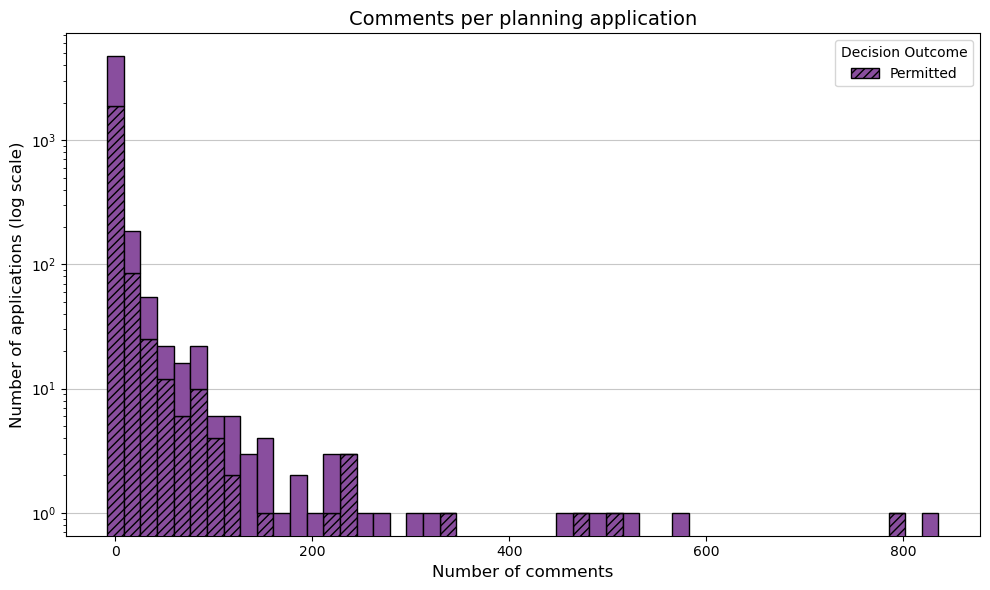

In [17]:
plt.figure(figsize=(10,6))

# Split data into two categories
permitted = application_df.loc[application_df['outcome'] == 'Permitted', 'comment_count']
not_permitted = application_df.loc[application_df['outcome'] != 'Permitted', 'comment_count']

# Common parameters
bins = 50

# Plot both datasets *in one call* for stacking
counts, bins, patches = plt.hist(
    [not_permitted, permitted],
    bins=bins,
    stacked=True,
    color=[casa_purple, casa_purple],
    edgecolor='black',
    alpha=1,
    align='left',
    label=['Permitted'],
    zorder=3
)

# Apply hatching only to the 'Permitted' bars (second group)
for patch in patches[0]:  # second dataset (index 1)
    patch.set_hatch('////')

# Log scale and labels
plt.yscale('log')
plt.title('Comments per planning application', fontsize=14)
plt.xlabel('Number of comments', fontsize=12)
plt.ylabel('Number of applications (log scale)', fontsize=12)
plt.grid(axis='y', alpha=0.7, zorder=0)
plt.legend(title='Decision Outcome')
plt.tight_layout()
plt.savefig("../results/figures/hist_comments_per_application_permitted.png", dpi=500)
plt.show()

### Applications and comments by residential build type 

In [18]:
esf = ElasticSearchFncs()
esf.check_connection()

Connected to Elastic Search


In [19]:
pld_df = esf.res_units_x_query(min_res_units=1, since_year="01/01/2021", to_year="01/05/2025")

In [20]:
pld_df = ppf.format_df(pld_df)

# this function adds a 'housing_type' column to the pld_df - which summarises the housing type based on the number of units of each type
pld_df = ppf.add_housing_type(pld_df)

application_df = pd.merge(application_df, pld_df[['lpa_app_no', 'housing_type']], left_on='lpa_app_no', right_on='lpa_app_no', how='left')

In [21]:
application_df.groupby('housing_type')['comment_count'].agg(['mean', 'count'])

,mean,count
housing_type,,
Market housing,4.317202,4360
Mixed affordable housing,18.430328,244
Mixed social housing,38.770833,48
Other,2.670732,82
Self-build housing,4.242105,285
Social housing,7.544444,90


In [22]:
application_df.columns

Index(['lpa_app_no', 'valid_date', 'decision_date', 'borough',
       'total_no_proposed_residential_units', 'total_no_affordable_units',
       'site_area', 'habitable_rooms_density', 'pp_id', 'uprn', 'status',
       'decision', 'street_name', 'site_name', 'site_number', 'polygon',
       'wgs84_polygon', 'description', 'comment_count', 'outcome',
       'housing_type'],
      dtype='object')

In [30]:
application_df['total_no_proposed_residential_units'].max()

1610

In [32]:
application_df.groupby('housing_type')['total_no_proposed_residential_units'].agg(['mean', 'max', 'count', 'sum'])

,mean,max,count,sum
housing_type,,,,
Market housing,6.247706,1312,4360,27240
Mixed affordable housing,69.774590,1158,244,17025
Mixed social housing,243.916667,1610,48,11708
Other,13.926829,772,82,1142
Self-build housing,1.508772,8,285,430
Social housing,8.633333,102,90,777


In [36]:
application_df['comment_count'].describe()

count    5231.000000
mean        5.810935
std        29.881602
min         0.000000
25%         0.000000
50%         0.000000
75%         2.500000
max       844.000000
Name: comment_count, dtype: float64

<Figure size 1200x1000 with 0 Axes>

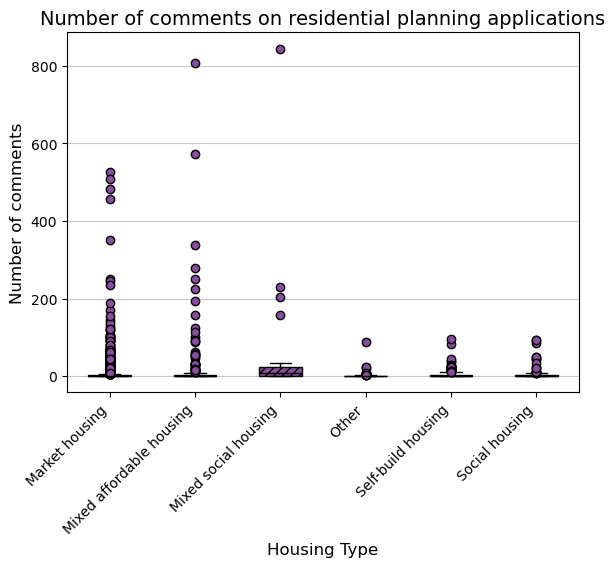

In [23]:
# box plot of comments per application by housing type
plt.figure(figsize=(12,10))

bp = application_df.boxplot(
    column='comment_count',
    by='housing_type',
    grid=False,
    patch_artist=True,
    boxprops=dict(facecolor=casa_purple, color='black', hatch='////'),
    medianprops=dict(color='black'),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    flierprops=dict(markerfacecolor=casa_purple, markeredgecolor='black'),
    zorder=3
)   

plt.title('Number of comments on residential planning applications', fontsize=14)
plt.suptitle('')  # Remove the automatic 'Boxplot grouped by ...' title
plt.xticks(rotation=45, ha='right')
plt.xlabel('Housing Type', fontsize=12)
plt.ylabel('Number of comments', fontsize=12)
plt.grid(axis='y', alpha=0.7, zorder=0)

plt.savefig("../results/figures/boxplot_comments_per_application_housing_type.png", dpi=500)
plt.show()

<Figure size 1200x1000 with 0 Axes>

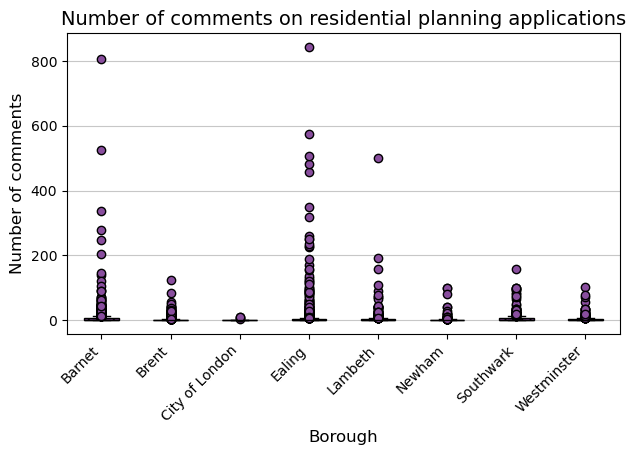

In [24]:
# box plot of comments per application by borough
plt.figure(figsize=(12,10))
color = "#894e9e"
bp = application_df.boxplot(
    column='comment_count',
    by='borough',
    grid=False,
    patch_artist=True,
    boxprops=dict(facecolor=color, color='black', hatch='////'),
    medianprops=dict(color='black'),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    flierprops=dict(markerfacecolor=color, markeredgecolor='black'),
    zorder=3
)
plt.title('Number of comments on residential planning applications', fontsize=14)
plt.suptitle('')  # Remove the automatic 'Boxplot grouped by ...' title
plt.xticks(rotation=45, ha='right')
plt.xlabel('Borough', fontsize=12)
plt.ylabel('Number of comments', fontsize=12)
plt.grid(axis='y', alpha=0.7, zorder=0)
plt.tight_layout()  
plt.savefig("../results/figures/boxplot_comments_per_application_borough.png", dpi=500)
plt.show()

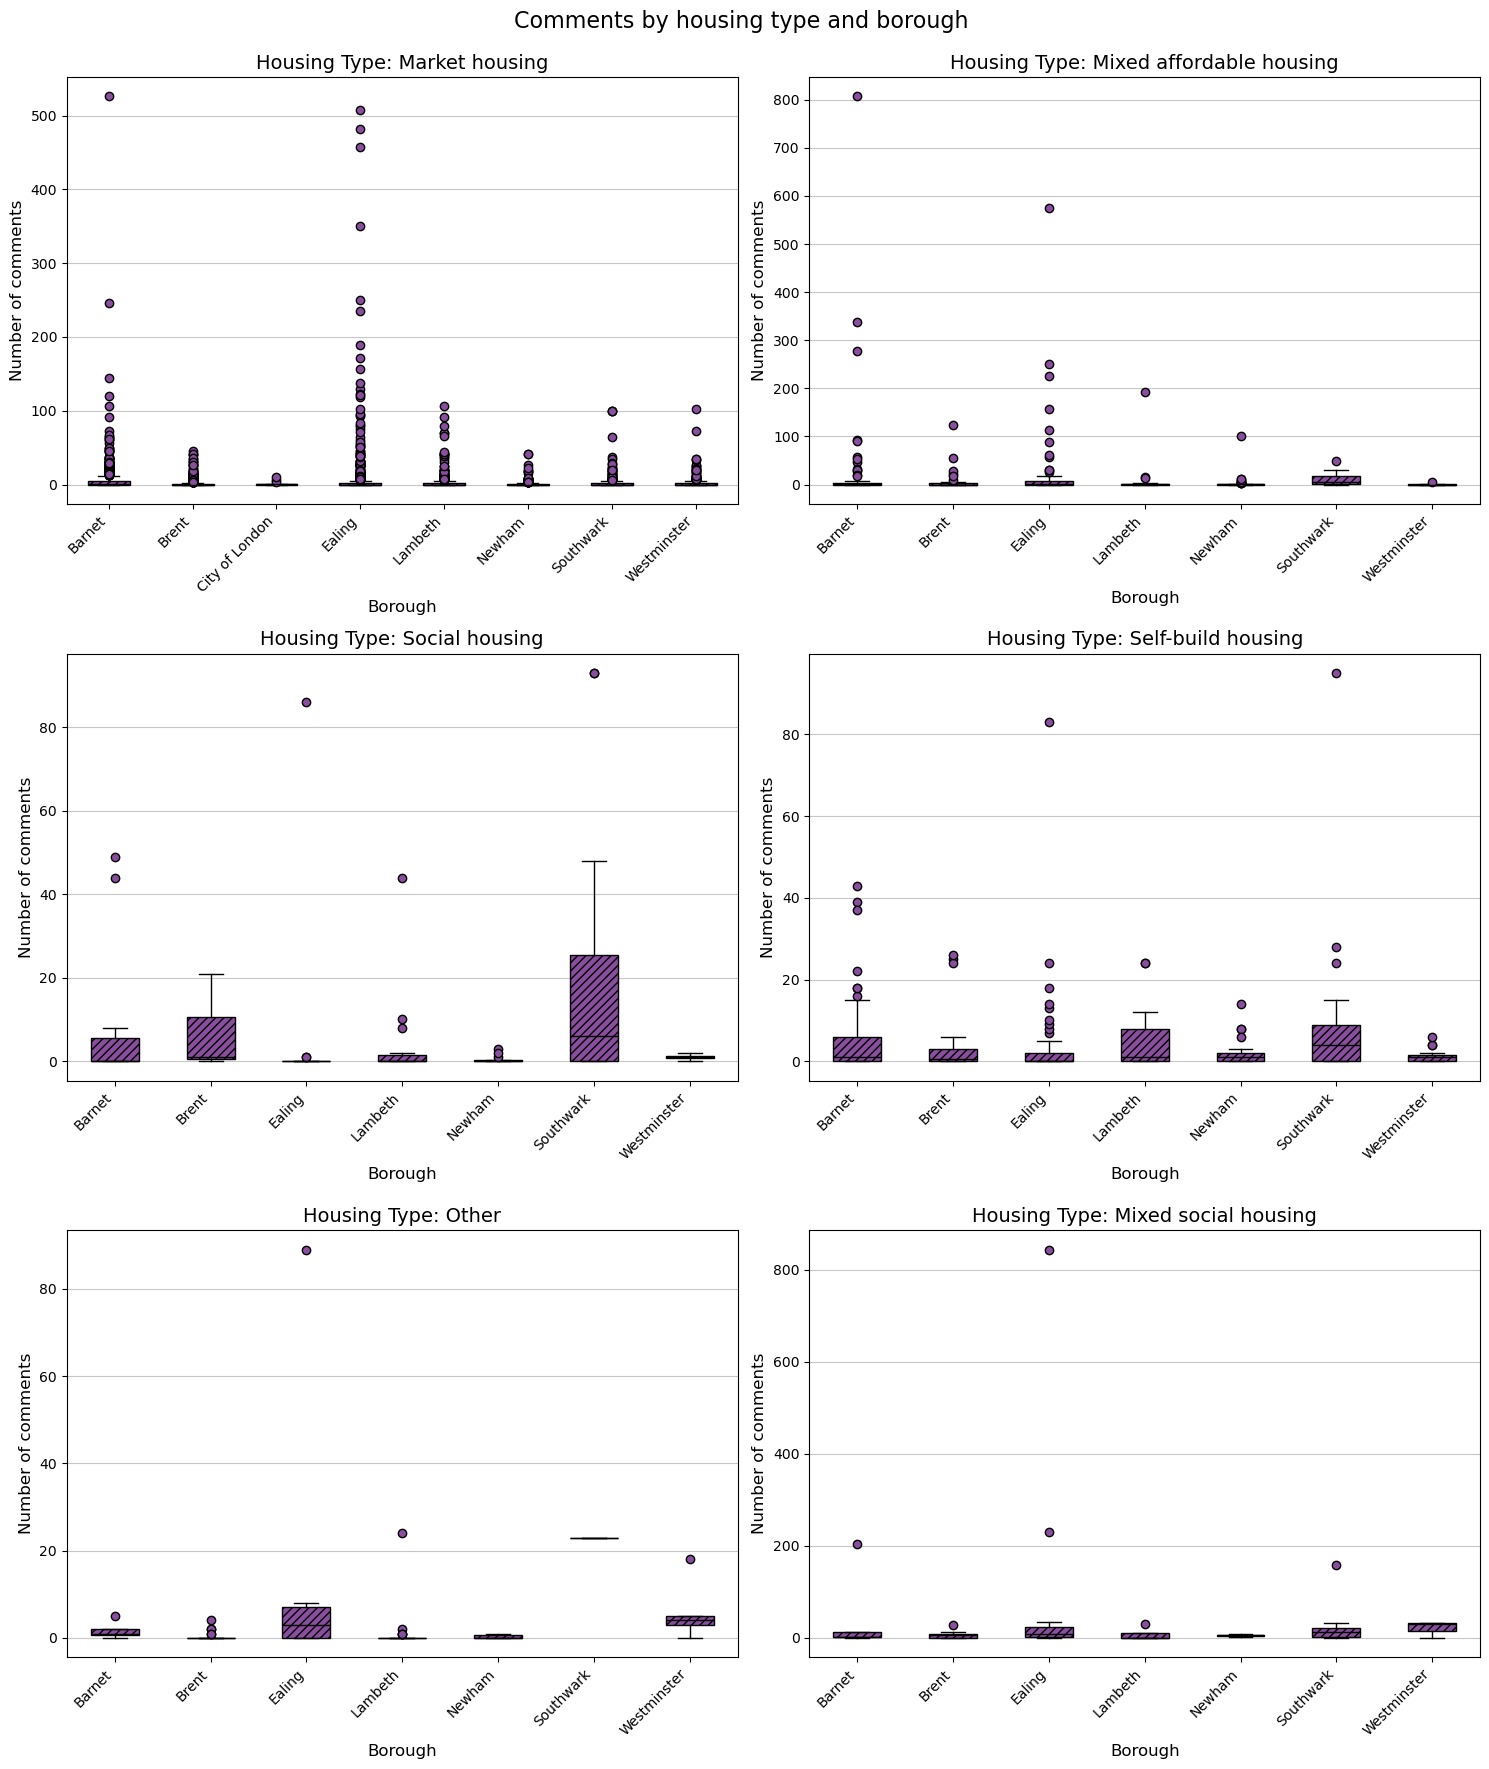

In [25]:
# plot grid of boxplots of comments per application by borough, by housing type
housing_types = application_df['housing_type'].dropna().unique()
n_types = len(housing_types)
n_cols = 2
n_rows = math.ceil(n_types / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 6), squeeze=False)
for i, housing_type in enumerate(housing_types):
    ax = axes[i // n_cols, i % n_cols]
    subset = application_df[application_df['housing_type'] == housing_type]
    color = "#894e9e"
    bp = subset.boxplot(
        column='comment_count',
        by='borough',
        grid=False,
        patch_artist=True,
        boxprops=dict(facecolor=color, color='black', hatch='////'),
        medianprops=dict(color='black'),
        whiskerprops=dict(color='black'),
        capprops=dict(color='black'),
        flierprops=dict(markerfacecolor=color, markeredgecolor='black'),
        ax=ax,
        zorder=3
    )
    ax.set_title(f'Housing Type: {housing_type}', fontsize=14)
    ax.set_xlabel('Borough', fontsize=12)
    ax.set_ylabel('Number of comments', fontsize=12)
    ax.grid(axis='y', alpha=0.7, zorder=0)
    plt.sca(ax)
    plt.xticks(rotation=45, ha='right')

plt.suptitle('Comments by housing type and borough \n', fontsize=16) 
plt.tight_layout()
plt.savefig("../results/figures/boxplot_comments_per_application_borough_housing_type.png", dpi=500)
plt.show()

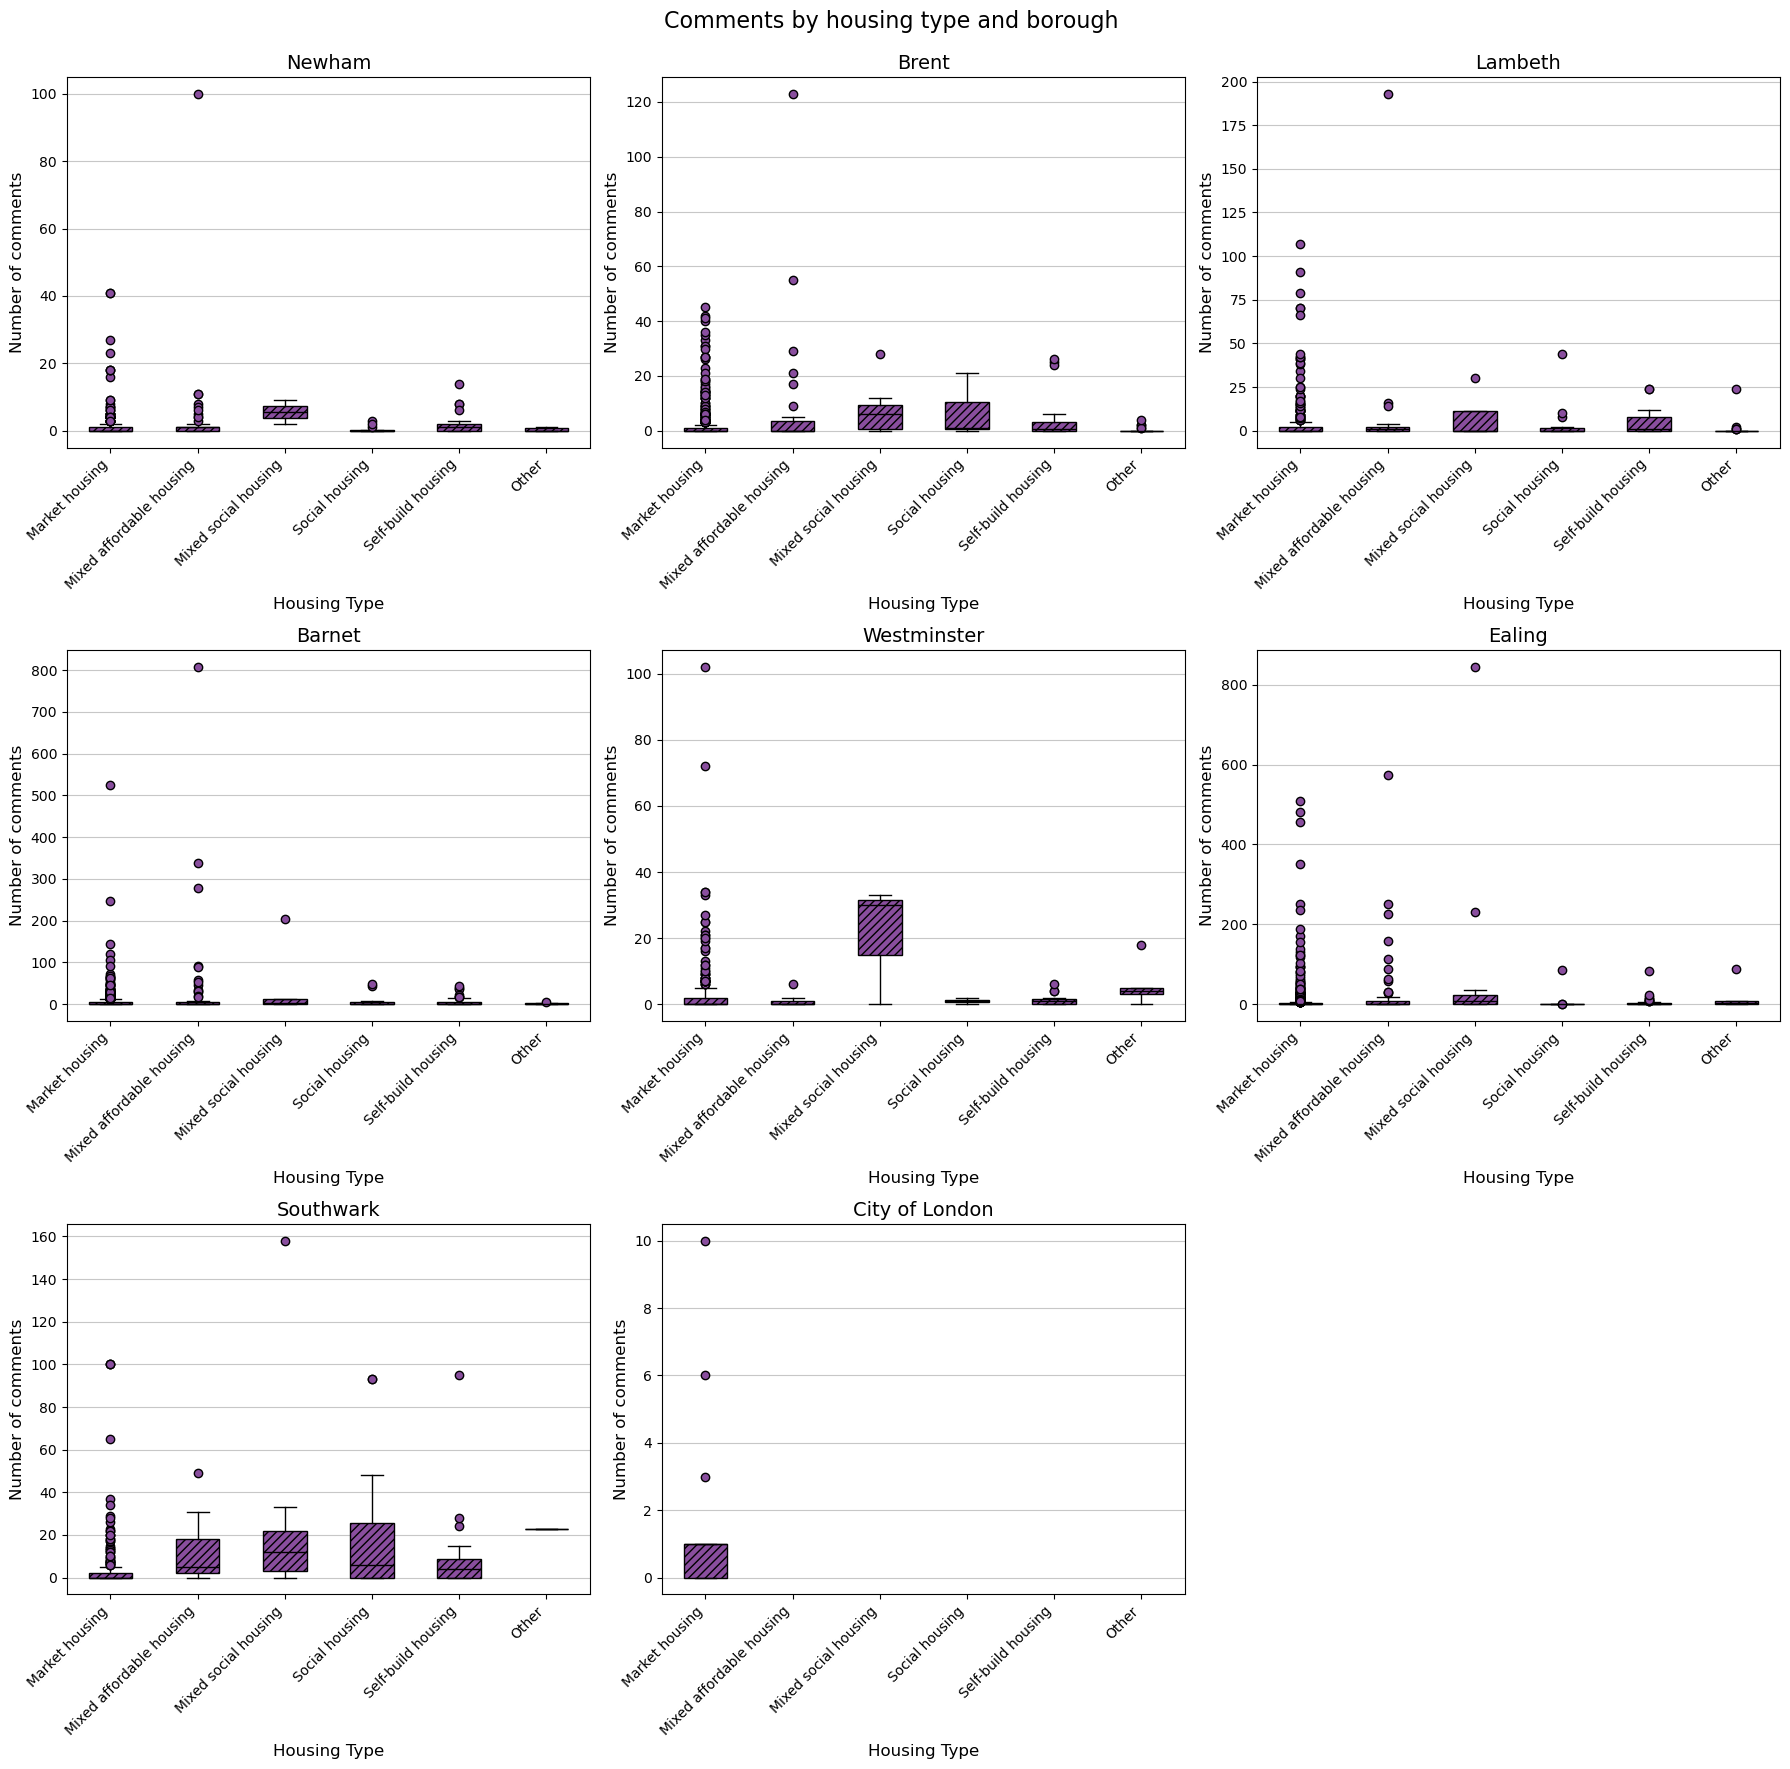

In [26]:
# Define desired order for housing types
housing_order = [
    'Market housing',
    'Mixed affordable housing',
    'Mixed social housing',
    'Social housing',
    'Self-build housing',
    'Other'
]

# Unique boroughs
boroughs = application_df['borough'].dropna().unique()
n_boroughs = len(boroughs)
n_cols = 3
n_rows = math.ceil(n_boroughs / n_cols)

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 6), squeeze=False)

for i, borough in enumerate(boroughs):
    ax = axes[i // n_cols, i % n_cols]
    subset = application_df[application_df['borough'] == borough]

    # Ensure housing_type is categorical with the specified order
    subset = subset.copy()
    subset['housing_type'] = pd.Categorical(subset['housing_type'], categories=housing_order, ordered=True)

    color = "#894e9e"
    bp = subset.boxplot(
        column='comment_count',
        by='housing_type',
        grid=False,
        patch_artist=True,
        boxprops=dict(facecolor=color, color='black', hatch='////'),
        medianprops=dict(color='black'),
        whiskerprops=dict(color='black'),
        capprops=dict(color='black'),
        flierprops=dict(markerfacecolor=color, markeredgecolor='black'),
        ax=ax,
        zorder=3
    )

    ax.set_title(f'{borough}', fontsize=14)
    ax.set_xlabel('Housing Type', fontsize=12)
    ax.set_ylabel('Number of comments', fontsize=12)
    ax.grid(axis='y', alpha=0.7, zorder=0)
    plt.sca(ax)
    plt.xticks(rotation=45, ha='right')

# Remove any unused axes (e.g., if only 8 boroughs)
for j in range(i + 1, n_rows * n_cols):
    fig.delaxes(axes[j // n_cols, j % n_cols])

plt.suptitle('Comments by housing type and borough \n', fontsize=16) 
plt.tight_layout()
plt.savefig("../results/figures/boxplot_comments_per_application_housing_type_borough.png", dpi=500)
plt.show()


In [27]:
# define colour palette
casa_purple = "#894e9e"
casa_green = "#abc766"
casa_pink = "#e16fca"
casa_yellow = "#f9dd73"
casa_blue = "#2e6260"
brown = "#a9746e"
grey = "#9f9f9fff"

# mapping from colours to housing types
housing_type_colors = {
    'Market housing': casa_purple,
    'Mixed affordable housing': casa_green,
    'Mixed social housing': casa_pink,
    'Social housing': casa_yellow,
    'Self-build housing': casa_blue,
    'Other': brown
}

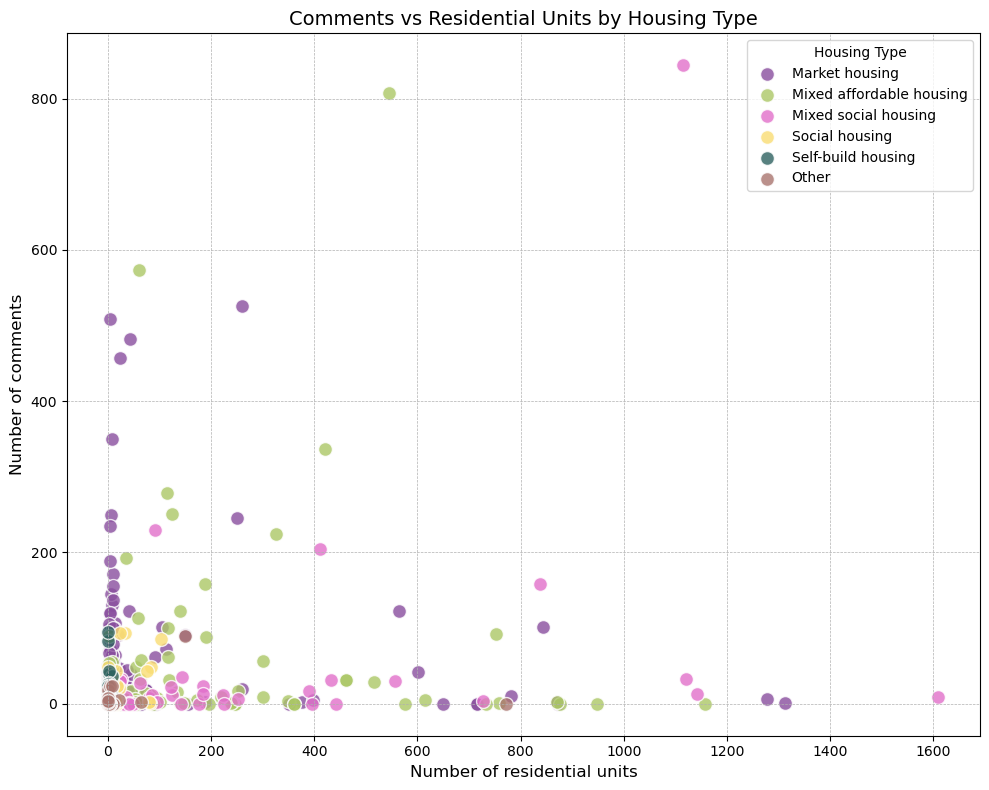

In [28]:
housing_order = [
    'Market housing',
    'Mixed affordable housing',
    'Mixed social housing',
    'Social housing',
    'Self-build housing',
    'Other'
]

plt.figure(figsize=(10,8))

# Loop through housing_order instead of unique()
for housing_type in housing_order:
    subset = application_df[application_df['housing_type'] == housing_type]
    if subset.empty:
        continue  # skip missing categories
    plt.scatter(
        subset['total_no_proposed_residential_units'],
        subset['comment_count'],
        color=housing_type_colors.get(housing_type, 'grey'),
        label=housing_type,
        alpha=0.8,
        edgecolors='w',
        s=100
    )

plt.xlabel('Number of residential units', fontsize=12)
plt.ylabel('Number of comments', fontsize=12)
plt.title('Comments vs Residential Units by Housing Type', fontsize=14)

# Force legend order to match housing_order
handles, labels = plt.gca().get_legend_handles_labels()
ordered = [(h, l) for l, h in sorted(zip(labels, handles), key=lambda x: housing_order.index(x[0]) if x[0] in housing_order else len(housing_order))]
plt.legend([h for h, _ in ordered], [l for _, l in ordered], title='Housing Type')

plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.tight_layout()
plt.savefig("../results/figures/scatter_comments_vs_residential_units.png", dpi=500)
plt.show()


Need to plot: 

- Comments by outcome - boxplot 
- Site area vs comments - scatter 
- Outcome vs units vs comments - boxplots 
- Units vs comments colour coded by outcome - scatter 